In [5]:
# general
import numpy as np
from numpy.random import PCG64, SeedSequence
import pandas as pd
import verde as vd
import xarray as xr
import skgstat as skg
from skgstat import models
import gstatsim as gsm
from scipy.interpolate import RBFInterpolator, griddata, RegularGridInterpolator
from scipy.stats import qmc
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import QuantileTransformer
from tqdm.auto import tqdm
from numba import njit, prange
from numba_progress import ProgressBar
import harmonica as hm

# plotting
import matplotlib.pyplot as plt
import cmocean
from cmcrameri import cm

# io
from tqdm.auto import tqdm
import os
from pathlib import Path
import time
import numbers
import warnings

import sys
sys.path.append('../src')

import gstatsim_custom as gsim

from gstatsim_custom import interpolate, utilities
import prisms
import importlib
importlib.reload(interpolate)
importlib.reload(prisms)

<module 'prisms' from 'G:\\antarctic_iceshelves\\random\\../src\\prisms.py'>

In [6]:
import gstools as gs
# structured field with a size 100x100 and a grid-size of 1x1
x = y = np.arange(100)
model = gs.Gaussian(dim=2, var=1, len_scale=10)
srf = gs.SRF(model)
field = srf.structured(pos=(x, y))

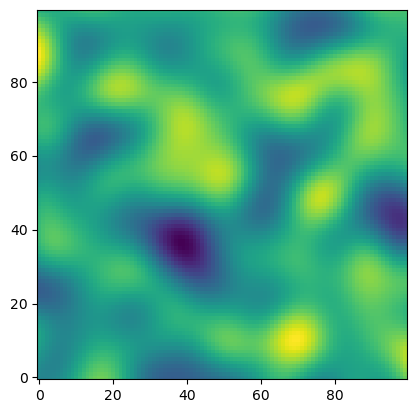

In [7]:
plt.pcolormesh(x, y, field)
plt.axis('scaled')
plt.show()

In [8]:
rng = np.random.default_rng(0)

from scipy.stats import qmc

lhs = qmc.LatinHypercube(2, rng=rng)
samples = lhs.integers(l_bounds=[0, 0], u_bounds=[x.size-1, y.size-1], n=60)

xloc = samples[:,0]
yloc = samples[:,1]
data = field[xloc, yloc]

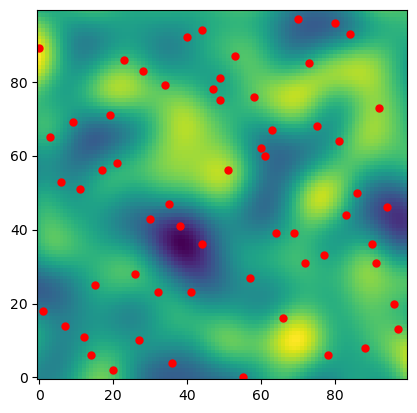

In [9]:
plt.pcolormesh(x, y, field)
plt.plot(xloc, yloc, 'ro', markersize=5)
plt.axis('scaled')
plt.show()

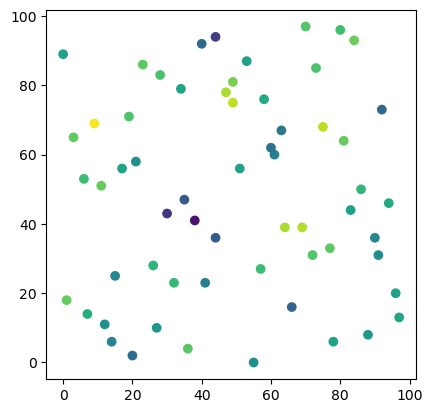

In [10]:
plt.scatter(xloc, yloc, c=data, vmin=np.min(field), vmax=np.max(field))
plt.axis('scaled')
plt.show()

In [11]:
def experimental_variogram(coords, data, nlags, maxlag):
    lags = pdist(coords)

    sqdiffs = np.square(np.subtract.outer(data, data))
    sqdiffs = sqdiffs[np.triu_indices_from(sqdiffs, k=1)]

    bins = np.linspace(0, maxlag, nlags)
    inds = np.digitize(lags, bins)-1

    bin_size = bins[1]-bins[0]
    bin_centers = np.arange(0+bin_size/2, np.max(bins), bin_size)

    emp_mean = np.full(bin_centers.size, np.nan)
    emp_counts = np.zeros(bin_centers.size)

    for i in range(len(bins)-1):
        count = np.count_nonzero(inds==i)
        emp_counts[i] = count
        if count == 0:
            continue
        emp_mean[i] = 0.5*np.mean(sqdiffs[inds==i])

    return emp_mean, bin_centers, emp_counts

In [12]:
emp_mean, bin_centers, counts = experimental_variogram(samples, data, 41, 100)

In [13]:
emp_mean

array([0.04810095, 0.14444671, 0.19567824, 0.49332755, 0.57429706,
       0.9020531 , 1.39931367, 1.85007109, 1.5275826 , 1.49490433,
       1.10584794, 0.95983871, 1.13382825, 1.75532974, 1.39447262,
       1.62028945, 1.76270333, 1.66957338, 1.21522743, 1.22368535,
       1.09987897, 1.42501143, 1.0580878 , 0.90594835, 1.26127625,
       1.00908483, 0.8730607 , 1.43724539, 0.58842556, 0.76988877,
       0.61352404, 0.99387048, 0.75754561, 0.91196245, 0.82393574,
       0.81440878, 0.80789333, 0.77614375, 0.70749975, 0.96409273])

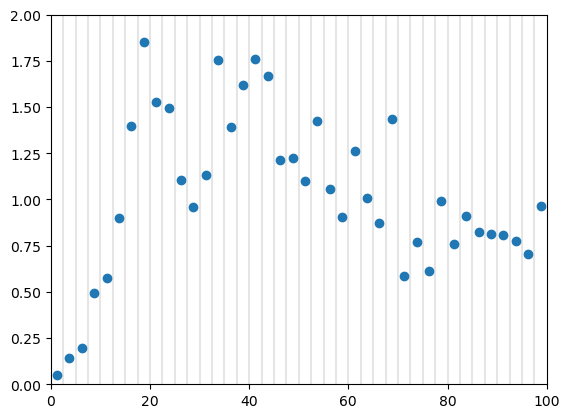

In [14]:
bin_width = bin_centers[1] - bin_centers[0]
bins_lower = bin_centers - bin_width/2

plt.plot(bin_centers, emp_mean, 'o')
plt.vlines(bins_lower, 0, 2, color='gray', alpha=0.2)
plt.ylim(0, 2)
plt.xlim(0, 100)
plt.show()

In [15]:
def fit_model(model, bins, semivar, p0, bounds=None, nugget=False):

    if bounds is None:
        if nugget==True:
            bounds = ([0, 0, 0], [np.max(bins), np.semivar(emp_mean), 0.2])
        else:
            bounds = ([0, 0, 0], [np.max(bins), np.semivar(emp_mean), 1e-5])
    else:
        if nugget==False:
            bounds[1][-1] = 1e-5

    if nugget==False:
        if p0[-1] > 0:
            p0[-1] = 0
        
    bins = bins[~np.isnan(semivar)]
    semivar = semivar[~np.isnan(semivar)]

    result = curve_fit(model, bins, semivar, p0=p0, bounds=bounds)
    popt = result[0]
    pcov = result[1]
    
    if nugget == False:
        popt[-1] = 0
    return result

In [16]:
from scipy.optimize import curve_fit

p0 = [20, 0.9, 0.01]
bounds = ([0, 0, 0], [np.max(bin_centers), np.nanmax(emp_mean), 0.2])

params, pcov = fit_model(models.gaussian, bin_centers, emp_mean, p0=p0, bounds=bounds, nugget=False)

In [17]:
params

array([20.1636234 ,  1.13165391,  0.        ])

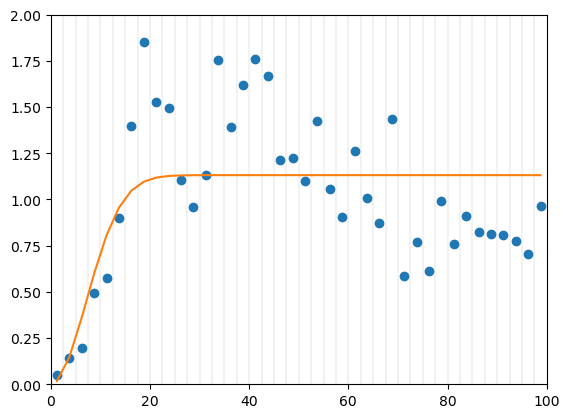

In [18]:
plt.plot(bin_centers, emp_mean, 'o')
plt.vlines(bins_lower, 0, 2, color='gray', alpha=0.1)
plt.plot(bin_centers, models.gaussian(bin_centers, *params))
plt.ylim(0, 2)
plt.xlim(0, 100)
plt.show()

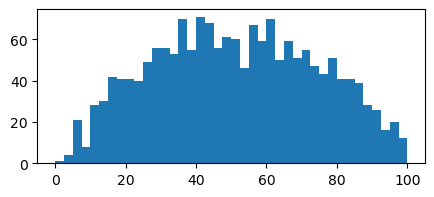

In [19]:
plt.figure(figsize=(5,2))
plt.bar(bin_centers, counts, width=(bin_centers[1]-bin_centers[0]))
plt.show()

In [20]:
V = skg.Variogram(samples, data, bin_func='even', n_lags=51, 
                   maxlag=100, normalize=False)

bc, exp = V.get_empirical(bin_center=True)

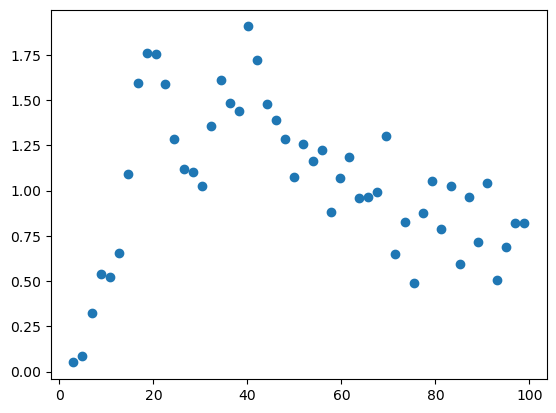

In [21]:
plt.plot(bc, exp, 'o')
plt.show()

C:\Users\mjfie\mambaforge\envs\cryo\lib\site-packages\skgstat\plotting\variogram_plot.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


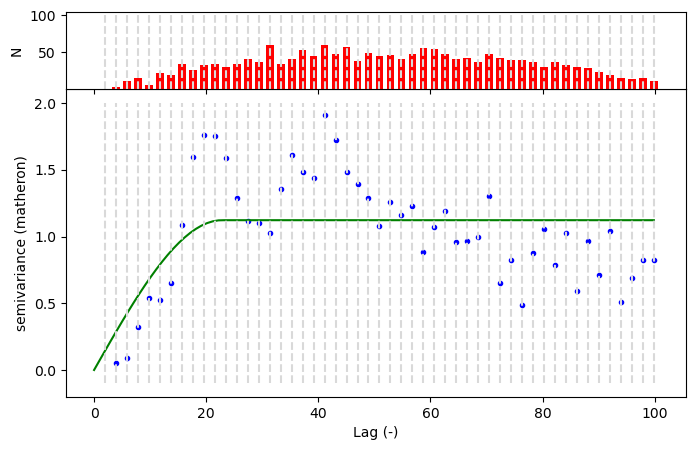

In [22]:
V.plot()
plt.show()

C:\Users\mjfie\mambaforge\envs\cryo\lib\site-packages\skgstat\plotting\variogram_dd_plot.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


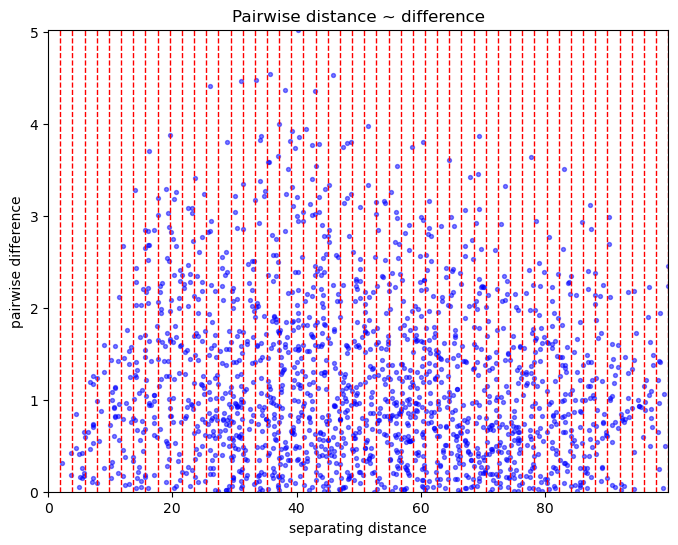

In [23]:
V.distance_difference_plot()
plt.show()

In [24]:
V.bins

array([ 1.95784093,  3.91568186,  5.87352278,  7.83136371,  9.78920464,
       11.74704557, 13.7048865 , 15.66272742, 17.62056835, 19.57840928,
       21.53625021, 23.49409114, 25.45193206, 27.40977299, 29.36761392,
       31.32545485, 33.28329578, 35.24113671, 37.19897763, 39.15681856,
       41.11465949, 43.07250042, 45.03034135, 46.98818227, 48.9460232 ,
       50.90386413, 52.86170506, 54.81954599, 56.77738691, 58.73522784,
       60.69306877, 62.6509097 , 64.60875063, 66.56659155, 68.52443248,
       70.48227341, 72.44011434, 74.39795527, 76.35579619, 78.31363712,
       80.27147805, 82.22931898, 84.18715991, 86.14500083, 88.10284176,
       90.06068269, 92.01852362, 93.97636455, 95.93420547, 97.8920464 ,
       99.84988733])

In [25]:
bc

array([ 0.97892046,  2.93676139,  4.89460232,  6.85244325,  8.81028418,
       10.7681251 , 12.72596603, 14.68380696, 16.64164789, 18.59948882,
       20.55732974, 22.51517067, 24.4730116 , 26.43085253, 28.38869346,
       30.34653438, 32.30437531, 34.26221624, 36.22005717, 38.1778981 ,
       40.13573903, 42.09357995, 44.05142088, 46.00926181, 47.96710274,
       49.92494367, 51.88278459, 53.84062552, 55.79846645, 57.75630738,
       59.71414831, 61.67198923, 63.62983016, 65.58767109, 67.54551202,
       69.50335295, 71.46119387, 73.4190348 , 75.37687573, 77.33471666,
       79.29255759, 81.25039851, 83.20823944, 85.16608037, 87.1239213 ,
       89.08176223, 91.03960315, 92.99744408, 94.95528501, 96.91312594,
       98.87096687])

In [26]:
bin_centers

array([ 1.25,  3.75,  6.25,  8.75, 11.25, 13.75, 16.25, 18.75, 21.25,
       23.75, 26.25, 28.75, 31.25, 33.75, 36.25, 38.75, 41.25, 43.75,
       46.25, 48.75, 51.25, 53.75, 56.25, 58.75, 61.25, 63.75, 66.25,
       68.75, 71.25, 73.75, 76.25, 78.75, 81.25, 83.75, 86.25, 88.75,
       91.25, 93.75, 96.25, 98.75])

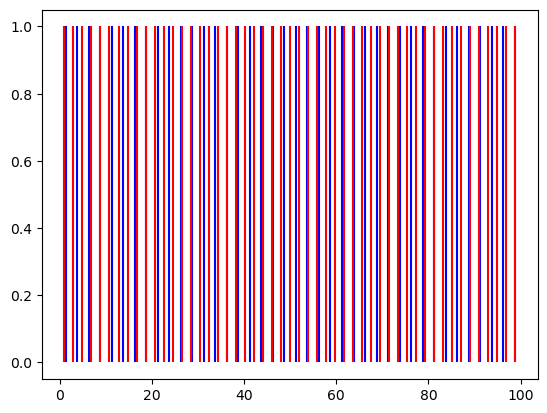

In [27]:
plt.vlines(bin_centers, 0, 1, color='blue')
plt.vlines(bc, 0, 1, color='red')
plt.show()

In [28]:
def gaussian_cov_norm(h, sill, nugget, **kwargs):
    return sill*np.exp(-4*h**2) - nugget

In [29]:
from sklearn.metrics import pairwise_distances

xx, yy = np.meshgrid(x, y)

X_b = np.stack([xx.flatten(), yy.flatten()]).T
D = pairwise_distances(X_b)**2

In [30]:
D.shape

(10000, 10000)

In [31]:
D2 = squareform(pdist(X_b))**2

In [32]:
np.allclose(D, D2)

True

In [33]:
D

array([[0.0000e+00, 1.0000e+00, 4.0000e+00, ..., 1.9210e+04, 1.9405e+04,
        1.9602e+04],
       [1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.9017e+04, 1.9210e+04,
        1.9405e+04],
       [4.0000e+00, 1.0000e+00, 0.0000e+00, ..., 1.8826e+04, 1.9017e+04,
        1.9210e+04],
       ...,
       [1.9210e+04, 1.9017e+04, 1.8826e+04, ..., 0.0000e+00, 1.0000e+00,
        4.0000e+00],
       [1.9405e+04, 1.9210e+04, 1.9017e+04, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [1.9602e+04, 1.9405e+04, 1.9210e+04, ..., 4.0000e+00, 1.0000e+00,
        0.0000e+00]], shape=(10000, 10000))

In [34]:
D2

array([[0.0000e+00, 1.0000e+00, 4.0000e+00, ..., 1.9210e+04, 1.9405e+04,
        1.9602e+04],
       [1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.9017e+04, 1.9210e+04,
        1.9405e+04],
       [4.0000e+00, 1.0000e+00, 0.0000e+00, ..., 1.8826e+04, 1.9017e+04,
        1.9210e+04],
       ...,
       [1.9210e+04, 1.9017e+04, 1.8826e+04, ..., 0.0000e+00, 1.0000e+00,
        4.0000e+00],
       [1.9405e+04, 1.9210e+04, 1.9017e+04, ..., 1.0000e+00, 0.0000e+00,
        1.0000e+00],
       [1.9602e+04, 1.9405e+04, 1.9210e+04, ..., 4.0000e+00, 1.0000e+00,
        0.0000e+00]], shape=(10000, 10000))

In [35]:
def gaussian_cov_norm(h, r, sill, nugget):
    return sill*np.exp(-4*h**2/r**2) - nugget

cov = gaussian_cov_norm(squareform(pdist(X_b)), 20, 1, 0) + np.diag(np.full(D.shape[0], 1e-10))

In [36]:
cov.shape

(10000, 10000)

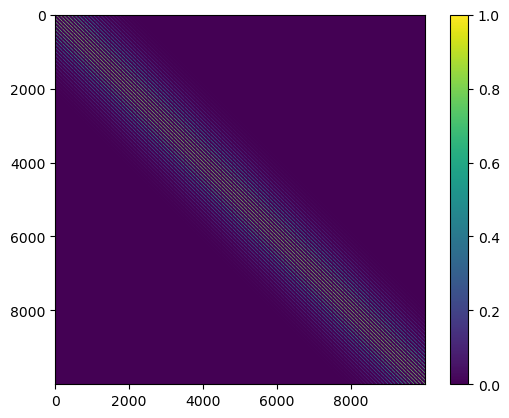

In [37]:
plt.imshow(cov)
plt.colorbar()
plt.show()

In [34]:
samples = rng.multivariate_normal(np.zeros(cov.shape[0]), cov, size=1, method='cholesky')
samples = samples.reshape((x.size, y.size))

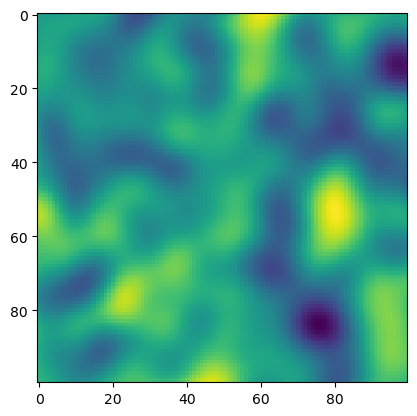

In [35]:
plt.imshow(samples)
plt.show()

In [36]:
field = samples

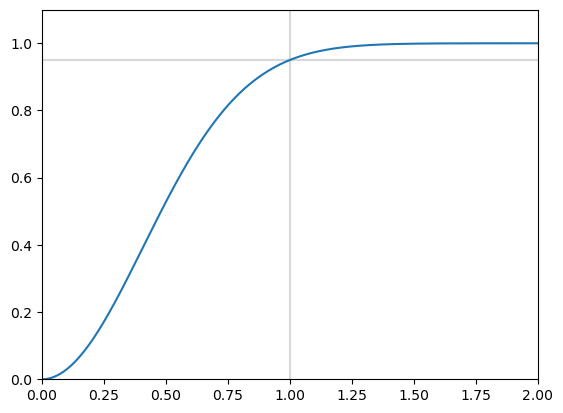

In [37]:
def gauss(h, d):
    return 1-np.exp(-3*h**2/d**2)

xi = np.linspace(0, 2, 1000)
gamma1 = gauss(xi, 1)

ind_eff = np.argmin(np.abs(gamma1-0.95))

plt.vlines(xi[ind_eff], 0, 1.1, color='gray', alpha=0.3)
plt.hlines(0.95, 0, 2, color='gray', alpha=0.3)
plt.plot(xi, gamma1)
plt.xlim(0, 2)
plt.ylim(0, 1.1)
plt.show()

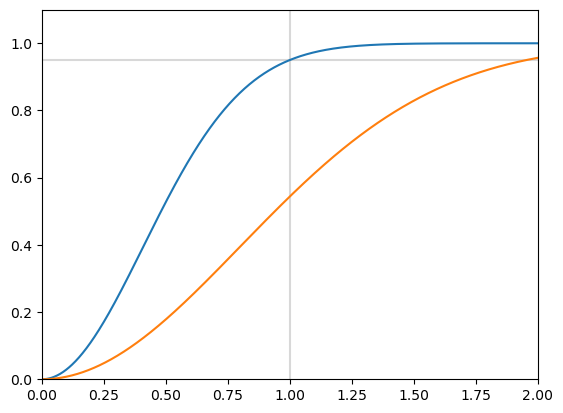

In [41]:
def gauss_gstools(h, d):
    return 1-np.exp(-1*(np.sqrt(np.pi)/2*h/d)**2)

gamma2 = gauss_gstools(xi, 1)

plt.vlines(xi[ind_eff], 0, 1.1, color='gray', alpha=0.3)
plt.hlines(0.95, 0, 2, color='gray', alpha=0.3)
plt.plot(xi, gamma1)
plt.plot(xi, gamma2)
plt.xlim(0, 2)
plt.ylim(0, 1.1)
plt.show()

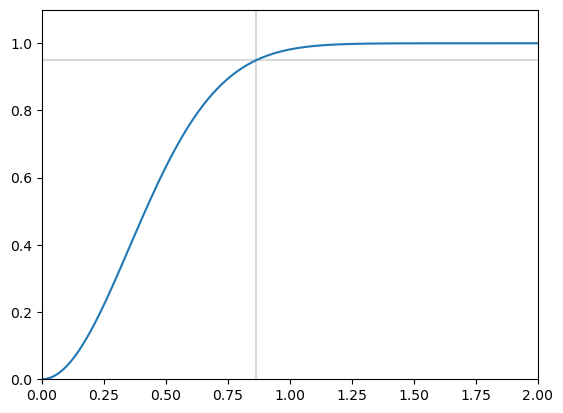

In [64]:
gamma3 = models.gaussian(xi, 1, 1, 0)
ind_eff = np.argmin(np.abs(gamma3-0.95))

plt.vlines(xi[ind_eff], 0, 1.1, color='gray', alpha=0.3)
plt.hlines(0.95, 0, 2, color='gray', alpha=0.3)
plt.plot(xi, gamma3)
plt.xlim(0, 2)
plt.ylim(0, 1.1)
plt.show()

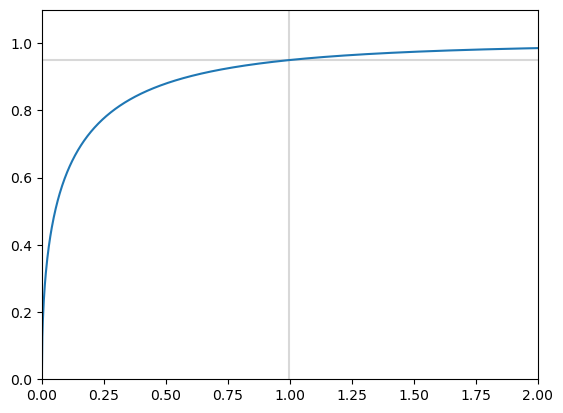

In [84]:
gamma3 = models.stable(xi, 1, 1, 0.5, 0)
ind_eff = np.argmin(np.abs(gamma3-0.95))

plt.vlines(xi[ind_eff], 0, 1.1, color='gray', alpha=0.3)
plt.hlines(0.95, 0, 2, color='gray', alpha=0.3)
plt.plot(xi, gamma3)
plt.xlim(0, 2)
plt.ylim(0, 1.1)
plt.show()

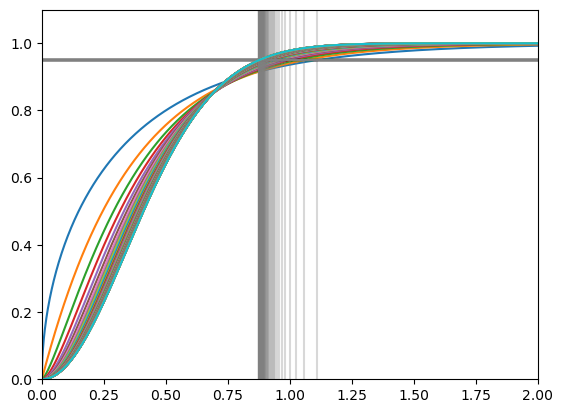

In [237]:
ss = np.arange(0.25, 20.25, 0.25)
xis = []
for s in ss:
    gamma = models.matern(xi, 1, 1, s, 0)
    ind_eff = np.argmin(np.abs(gamma-0.95))
    plt.vlines(xi[ind_eff], 0, 1.1, color='gray', alpha=0.3)
    plt.hlines(0.95, 0, 2, color='gray', alpha=0.3)
    plt.plot(xi, gamma)
    xis.append(xi[ind_eff])
plt.xlim(0, 2)
plt.ylim(0, 1.1)
plt.show()

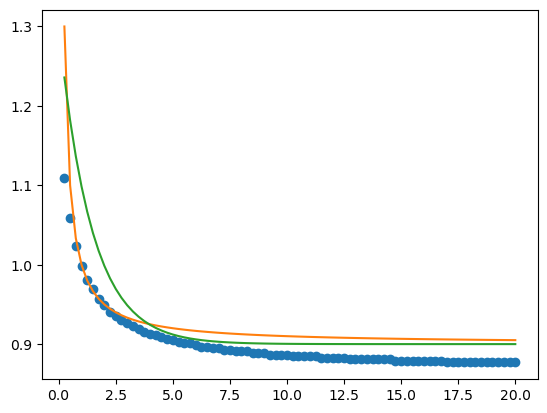

In [238]:
plt.plot(ss, xis, 'o')
plt.plot(ss, 1/2/(5*np.array(ss))+0.9)
plt.plot(ss, 0.4*np.exp(-0.7*np.array(ss))+0.9)
plt.show()

In [239]:
def tmp(x, a, b):
    return 1/(a*x+b)

def tmp2(x, a, b, c):
    return a*np.exp(b*x)+c

# bounds = ([1, 0], [10, 1])
# p0 = [3, 0.85]
ss = np.array(ss)

p0 = [0.4, -0.7, 0.9]

result_tmp = curve_fit(tmp2, ss, xis, p0=p0)
result_tmp

(array([ 0.22945655, -0.57119018,  0.88301606]),
 array([[ 3.45843460e-05, -8.83379211e-05,  2.84341597e-07],
        [-8.83379211e-05,  4.69023331e-04, -9.26901864e-06],
        [ 2.84341597e-07, -9.26901864e-06,  8.61813990e-07]]))

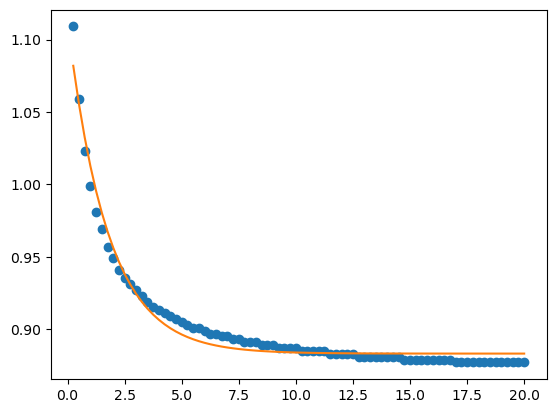

In [240]:
plt.plot(ss, xis, 'o')
#plt.plot(ss, 1/(result_tmp[0][0]*np.array(ss))+result_tmp[0][1])
plt.plot(ss, tmp2(ss, *result_tmp[0]))
plt.show()

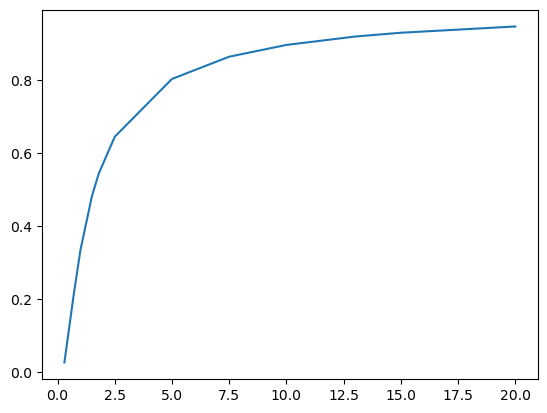

In [98]:
tmp = 1/3**(1/np.array(ss))

plt.plot(ss, tmp)

In [179]:
import math
from scipy import special

def matern_tmp(h, r, c0, s, b=0):
    # prepare parameters
     # a = r / np.sqrt(3)
    scale = 0.45246434*np.exp(-0.70449189*s)+1.7863836
    a = r /scale

    # calculate
    return b + c0 * (1. - (2 / special.gamma(s)) *
                     np.power((h * np.sqrt(s)) / a, s) *
                     special.kv(s, 2 * ((h * np.sqrt(s)) / a))
                     )

C:\Users\mjfie\AppData\Local\Temp\ipykernel_27672\262360694.py:11: RuntimeWarning: invalid value encountered in multiply
  return b + c0 * (1. - (2 / special.gamma(s)) *


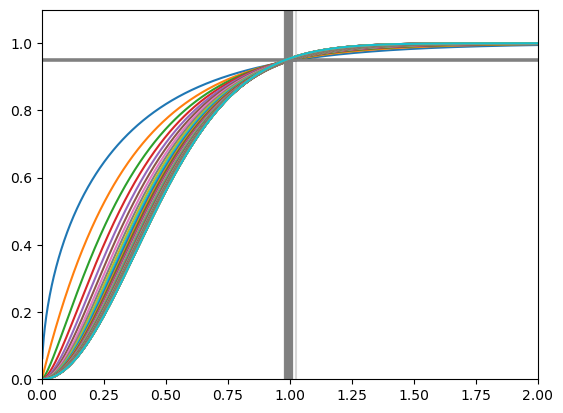

In [180]:
ss = np.arange(0.25, 20.25, 0.25)
xis = []
for s in ss:
    gamma = matern_tmp(xi, 1, 1, s, 0)
    ind_eff = np.nanargmin(np.abs(gamma-0.95))
    plt.vlines(xi[ind_eff], 0, 1.1, color='gray', alpha=0.3)
    plt.hlines(0.95, 0, 2, color='gray', alpha=0.3)
    plt.plot(xi, gamma)
    xis.append(xi[ind_eff])
plt.xlim(0, 2)
plt.ylim(0, 1.1)
plt.show()

In [121]:
xis

[np.float64(1.0990990990990992),
 np.float64(1.029029029029029),
 np.float64(0.998998998998999),
 np.float64(0.968968968968969),
 np.float64(0.954954954954955),
 np.float64(0.934934934934935),
 np.float64(0.9049049049049049),
 np.float64(0.8928928928928929),
 np.float64(0.8868868868868869),
 np.float64(0.8808808808808809),
 np.float64(0.8788788788788788),
 np.float64(0.8768768768768769)]

In [83]:
def cauchy(h, rang, sill, alpha, nugget):
    return sill*(1-(1+(h/rang)**2)**(-alpha))

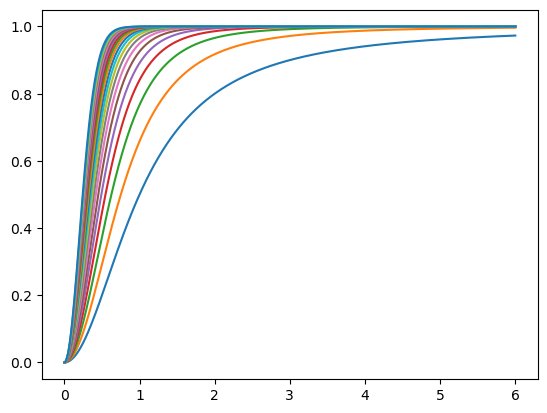

In [93]:
xi = np.linspace(0,6, 1000)

alphas = np.linspace(1, 12, 21)
xis = []
for alpha in alphas:
    g_i = cauchy(xi, 1, 1, alpha, 0)
    ind_eff = np.argmin(np.abs(g_i-0.95))
    xis.append(xi[ind_eff])
    plt.plot(xi, g_i)
plt.show()

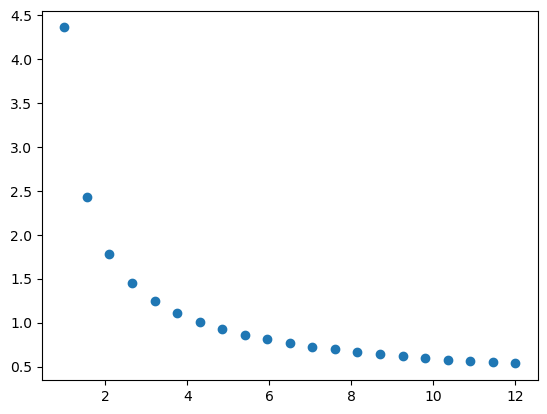

In [94]:
plt.plot(alphas, xis, 'o')
plt.show()

In [95]:
from numpy.polynomial import Polynomial

In [100]:
result = Polynomial.fit(alphas, xis, deg=7)
result

Polynomial([ 0.73793754, -0.26552338,  1.12152387, -1.94725476, -3.12145152,
        4.78504238,  3.68570262, -4.4766851 ], domain=[ 1., 12.], window=[-1.,  1.], symbol='x')

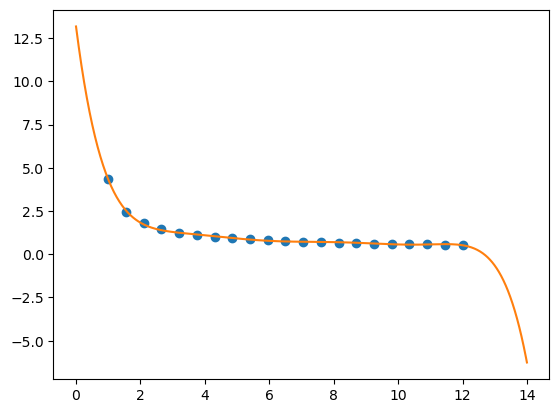

In [103]:
tmp = np.linspace(0, 14, 1000)

plt.plot(alphas, xis, 'o')
plt.plot(tmp, result(tmp), '-')
plt.show()

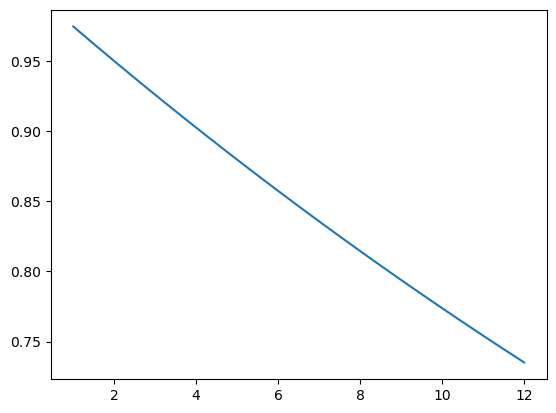

In [104]:
scale = 1/np.sqrt(0.05**(-alphas)-1)
# scale = np.sqrt(-1*1**2/0.95**(-alphas))
scale = 1/(1/0.95)**(1/2*alphas)

plt.plot(alphas, scale)
plt.show()

In [77]:
def cauchy_scale(h, rang, sill, alpha, nugget):
    a = rang/np.sqrt(0.05**(-alpha)-1)
    return sill*(1-(1+(h/a)**2)**(-alpha))

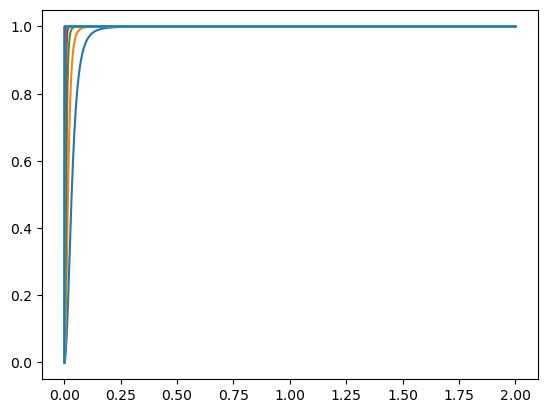

In [78]:
xi = np.linspace(0, 2, 1000)

alphas = np.linspace(2, 10, 21)
xis = []
for alpha in alphas:
    g_i = cauchy_scale(xi, 1, 1, alpha, 0)
    ind_eff = np.argmin(np.abs(g_i-0.95))
    xis.append(xi[ind_eff])
    plt.plot(xi, g_i)
plt.show()

In [ ]:
cov = gaussian_cov_norm(squareform(pdist(X_b)), 20, 1, 0) + np.diag(np.full(D.shape[0], 1e-10))